# Heart

In [55]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")





In [56]:
df=pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## EDA

In [57]:
df.shape

(918, 12)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [59]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

<Axes: xlabel='HeartDisease', ylabel='count'>

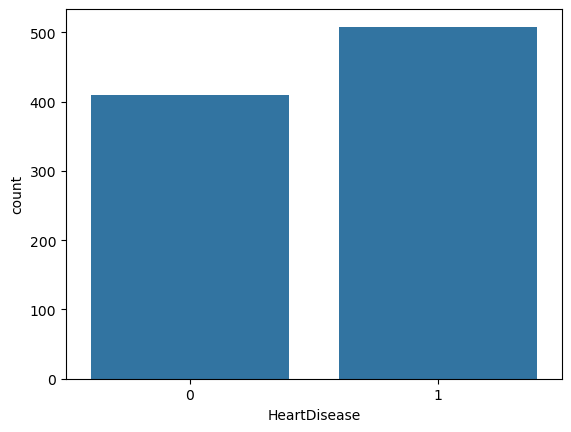

In [62]:
sns.countplot(x=df["HeartDisease"])

In [63]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

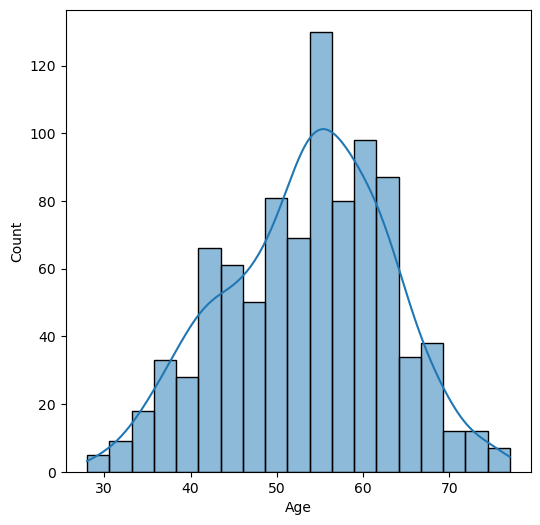

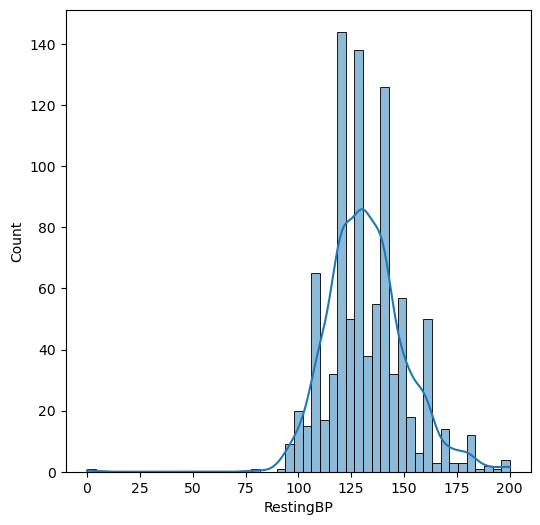

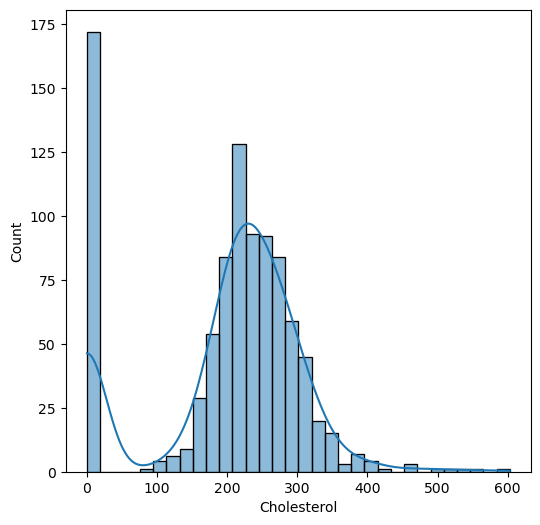

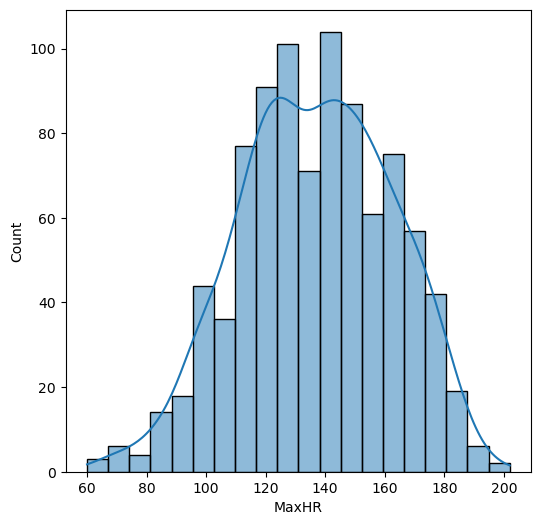

In [64]:
dist_columns=["Age","RestingBP","Cholesterol","MaxHR"]

for col in dist_columns:
    plt.figure(figsize=(6,6))
    sns.histplot(data=df,x=col,kde=True)


In [65]:
ch_mean=df.loc[df["Cholesterol"]!=0,"Cholesterol"].mean()
ch_mean

np.float64(244.6353887399464)

In [66]:
df["Cholesterol"]=df["Cholesterol"].replace(0,ch_mean)
df["Cholesterol"]=df["Cholesterol"].round(2)
df["Cholesterol"].value_counts()

Cholesterol
244.64    172
254.00     11
220.00     10
223.00     10
204.00      9
         ... 
353.00      1
278.00      1
157.00      1
176.00      1
131.00      1
Name: count, Length: 222, dtype: int64

In [67]:
df["RestingBP"]=df["RestingBP"].replace(0,ch_mean)
df["RestingBP"]=df["RestingBP"].round(2)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


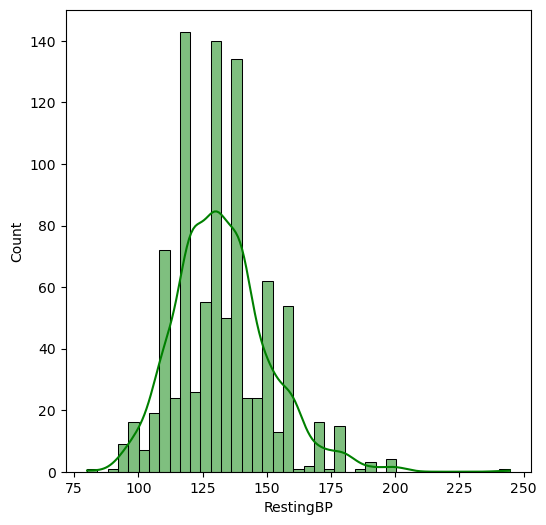

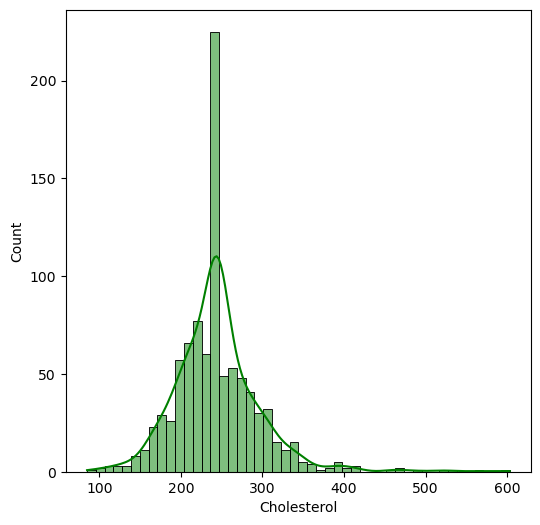

In [68]:
dist_columns=["RestingBP","Cholesterol"]

for col in dist_columns:
    plt.figure(figsize=(6,6))
    sns.histplot(data=df,x=col,kde=True,color="green")


<Axes: xlabel='Sex', ylabel='count'>

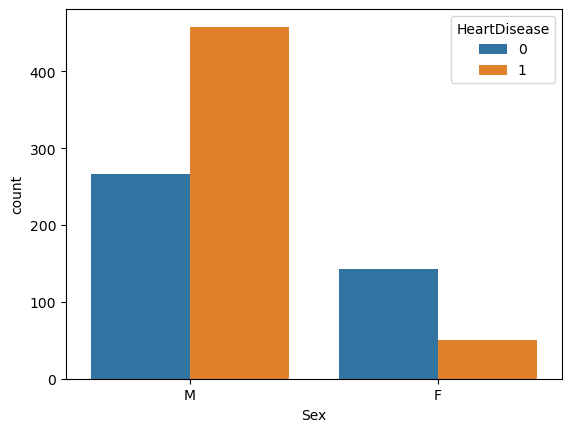

In [69]:
sns.countplot(x=df["Sex"],hue=df["HeartDisease"])

<Axes: xlabel='ChestPainType', ylabel='count'>

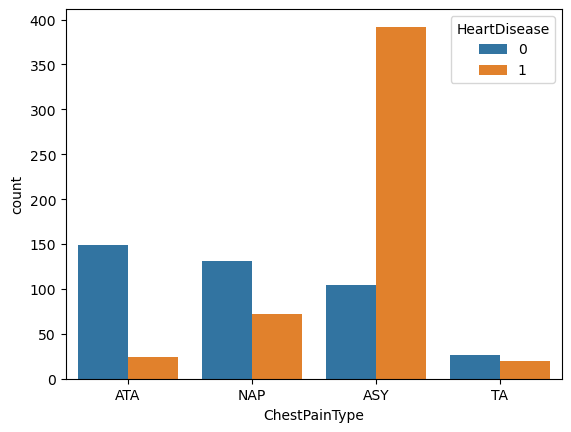

In [70]:
sns.countplot(x=df["ChestPainType"],hue=df["HeartDisease"])

<Axes: xlabel='FastingBS', ylabel='count'>

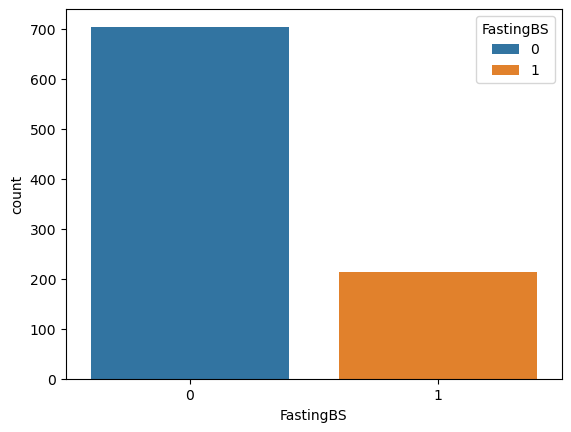

In [71]:
sns.countplot(x=df["FastingBS"],hue=df["FastingBS"])

Text(0.5, 1.0, 'Corelation matrix of Heart Diseases features')

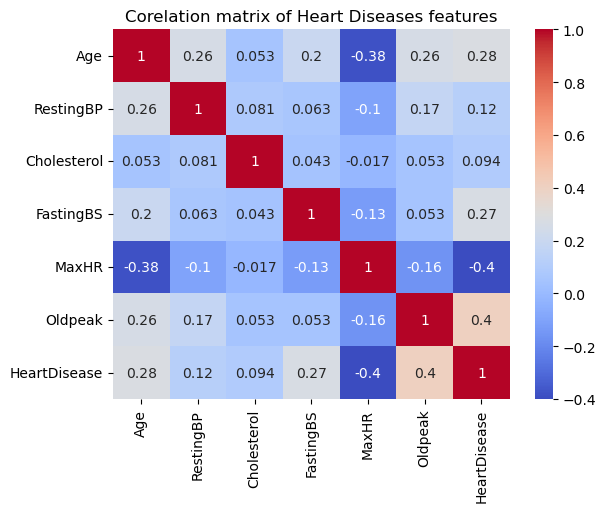

In [72]:
numeric_df=df.select_dtypes(include="number")

sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.title("Corelation matrix of Heart Diseases features")

In [73]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


# Encoding

In [74]:
df["ExerciseAngina"]=df["ExerciseAngina"].map({"N":0,"Y":1})
df["Sex"]=df["Sex"].map({"M":0,"F":1})



In [75]:
df=pd.get_dummies(df,drop_first=True)

In [76]:
df=df.astype(int)
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,0,0,0,0,1,0,1,0,0,1


## Feature Scaling

In [77]:
from sklearn.preprocessing import StandardScaler

feature_col=["Age","RestingBP","Cholesterol","MaxHR"]
scalar=StandardScaler()

df[feature_col]=scalar.fit_transform(df[feature_col])
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0,0.399826,0.834754,0,1.382928,0,0,0,1,0,0,1,0,0,1
1,-0.478484,1,1.489614,-1.210675,0,0.754157,0,1,1,0,1,0,1,0,1,0
2,-1.751359,0,-0.145068,0.722161,0,-1.525138,0,0,0,1,0,0,0,1,0,1
3,-0.584556,1,0.290847,-0.572651,0,-1.132156,1,1,1,0,0,0,1,0,1,0
4,0.051881,0,0.944720,-0.929194,0,-0.581981,0,0,0,0,1,0,1,0,0,1
